In [4]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate 20 records of Experience (between 1 and 20 years)
experience = np.sort(np.random.uniform(1, 20, 20).round(1))

# Generate Salary with a base, a multiplier for experience, and random "noise"
# Real-world data isn't a perfect line; 'noise' represents individual negotiation/skills
base_salary = 35000
experience_multiplier = 5500
noise = np.random.normal(0, 4500, 20) # Random variation of +/- $4500

salary = (base_salary + (experience * experience_multiplier) + noise).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'Years_Experience': experience,
    'Salary_USD': salary
})

print(f"Dataset for Regression (Generated: March 2026)")
print(df)

Dataset for Regression (Generated: March 2026)
    Years_Experience  Salary_USD
0                1.4       38142
1                2.1       47964
2                4.0       52913
3                4.0       50644
4                4.5       66345
5                4.5       58734
6                5.0       62803
7                6.5       64338
8                6.8       69950
9                8.1       80049
10               9.2       80420
11              11.0       97190
12              12.4      100497
13              12.4      101887
14              14.5      112042
15              14.9      125285
16              16.8      127339
17              17.5      126490
18              19.1      143751
19              19.4      136206


In [8]:
df.describe()

,Years_Experience,Salary_USD
count,20.000000,20.00000
mean,9.705000,87149.45000
std,5.845869,32871.51504
min,1.400000,38142.00000
25%,4.500000,61785.75000
50%,8.650000,80234.50000
75%,14.600000,115352.75000
max,19.400000,143751.00000


In [ ]:
df.corr() # based on below output if we have correlation above 0.7 then we can say that there is a strong correlation between the two variables. In this case, we can see that the correlation coefficient is 0.95, which indicates a very strong positive correlation between years of experience and salary. This means that as years of experience increases, salary tends to increase as well.

,Years_Experience,Salary_USD
Years_Experience,1.000000,0.992183
Salary_USD,0.992183,1.000000


<Axes: >

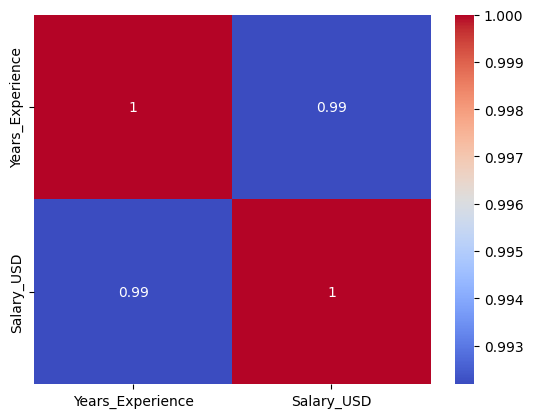

In [30]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")


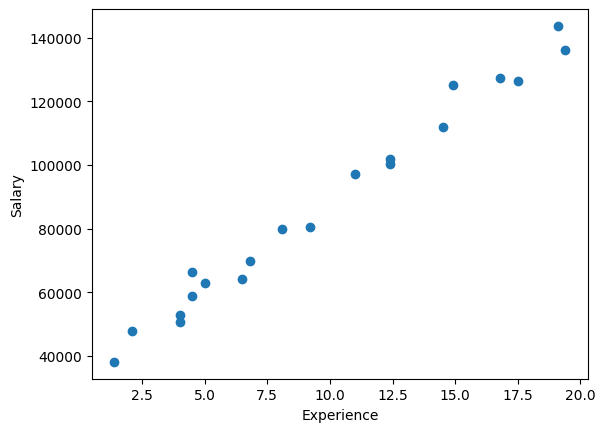

In [ ]:
import matplotlib.pyplot as plt

# check graph to determine if there is a linear relationship between the two variables
plt.scatter(df['Years_Experience'], df['Salary_USD'])
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

In [11]:
X = df[["Years_Experience"]]   # feature
y = df["Salary_USD"]         # target

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# fit baseline model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: 32923.126114792685
Coefficient: [5552.07321216]


In [ ]:
# Equation of the line: Salary = Intercept + Coefficient * Years of Experience
# salary = intercept + coefficient * experience

In [14]:
y_pred = model.predict(X_test)

In [15]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison)

    Actual      Predicted
0    38142   40696.028612
17  126490  130084.407328
15  125285  115649.016976
1    47964   44582.479860


In [ ]:
# Evaluate Model performance

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)  # MAE (Mean Absolute Error)


MAE: 4791.484775774816


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse) # MSE (Mean Squared Error)

MSE: 30932418.37032971


In [18]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)  # RMSE (Root Mean Squared Error)

RMSE: 5561.692042025495


In [19]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)  # R2 Score (Coefficient of Determination) - measures how well the model explains the variance in the target variable. A score of 1 indicates perfect prediction, while a score of 0 indicates that the model does not explain any of the variance. In this case, an R2 score of 0.95 suggests that the model explains 95% of the variance in salary based on years of experience, which is a very good fit.

R2 Score: 0.9820954514685762


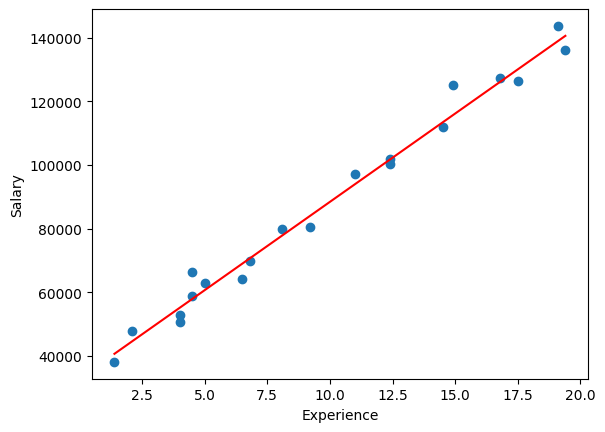

In [20]:
# plot regression line 
plt.scatter(X, y)

plt.plot(X, model.predict(X), color="red")

plt.xlabel("Experience")
plt.ylabel("Salary")

plt.show()

In [22]:
# Residual Analysis
residuals = y_test - y_pred
residuals

0    -2554.028612
17   -3594.407328
15    9635.983024
1     3381.520140
Name: Salary_USD, dtype: float64

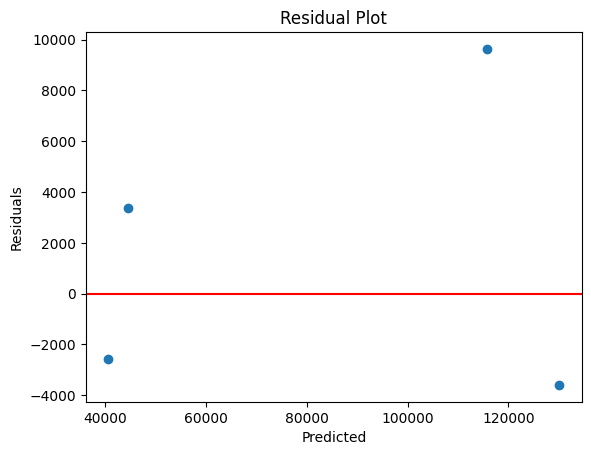

In [23]:
plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='r')

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [ ]:
# Check Multicollinearity (VIF)

# Since we only have one feature, multicollinearity doesn't apply.
# But here's how you do it when multiple features exist.

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = pd.DataFrame()
X_vif["feature"] = X.columns

X_vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(X_vif)

In [25]:
# Try Regularization

# Ridge Regression

from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)
ridge_pred

array([ 40804.30371883, 129987.2946027 , 115585.07247238,  44681.82506161])

In [26]:
print("Ridge R2:", r2_score(y_test, ridge_pred))

Ridge R2: 0.9820302575670942


In [27]:
# lasso Regression
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, lasso_pred))

Lasso R2: 0.982095277793659


In [28]:
# compare models

results = pd.DataFrame({
    "Model":["Linear","Ridge","Lasso"],
    "R2":[
        r2_score(y_test,y_pred),
        r2_score(y_test,ridge_pred),
        r2_score(y_test,lasso_pred)
    ]
})

print(results)

    Model        R2
0  Linear  0.982095
1   Ridge  0.982030
2   Lasso  0.982095


In [29]:
# cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

print("CV Score:", scores.mean())

CV Score: 0.016173835049062845
